<a href="https://colab.research.google.com/github/Thirupathi1356/Computer-Vision-Deep-Learning-/blob/main/Advance%20Computer%20Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import library

In [ ]:
#core libraries
import tensorflow as tf  #main deep learning library
import numpy as np       #for numerical operation (array,math)
import matplotlib.pyplot as plt #for plotting graphs and images

#dataset
from tensorflow.keras.datasets import cifar10  #cifar-10 image dataset

#model and layers
from tensorflow.keras import layers, models #to build neural network models

#pretrained model
from tensorflow.keras.applications import MobileNetV2   #pretrained CNN model

#utilities
from sklearn.metrics import classification_report, confusion_matrix  #for evaluation of model
import seaborn as sns  #for visualization of confusion matrix

load dataset

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print("train shape:",x_train.shape)
print("test shape :",x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
train shape: (50000, 32, 32, 3)
test shape : (10000, 32, 32, 3)


normalize

In [ ]:
# Normalize pixel values (0–255 -> 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

data augment

In [ ]:
# Data augmentation helps the model learn better by showing slightly modified images
# This reduces overfitting and improves performance on new data

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),     # Randomly flips images left ↔ right
    layers.RandomRotation(0.1),          # Slightly rotates images (10% range)
    layers.RandomZoom(0.1)               # Slightly zooms in/out
])

load pretrained model

In [ ]:
# Load MobileNetV2 model without the final classification layer (top layers)
base_model = MobileNetV2(input_shape=(32,32,3),
                         include_top=False,       # Remove default output layer
                         weights='imagenet')      # Use pretrained weights from ImageNet

# Freeze the base model so its learned features are not changed during training
base_model.trainable = False

/tmp/ipykernel_6524/3232108708.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(32,32,3),


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


build advanced model

In [ ]:
from tensorflow.keras import layers, models # Temporarily added import for models and layers
model = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

compile mode

In [ ]:
# Compile the model (configure how it learns)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # Optimizer to update weights
    loss='sparse_categorical_crossentropy',  # Loss function for multi-class classification
    metrics=['accuracy']  # Metric to track performance
)

add callbacks

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

train model

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.2584 - loss: 2.0140 - val_accuracy: 0.2776 - val_loss: 2.0723
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.2638 - loss: 2.0024 - val_accuracy: 0.2983 - val_loss: 2.0401
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.2678 - loss: 1.9971 - val_accuracy: 0.2910 - val_loss: 2.0723
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.2641 - loss: 1.9993 - val_accuracy: 0.3017 - val_loss: 2.0869
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.2710 - loss: 1.9893 - val_accuracy: 0.2944 - val_loss: 2.0660


fine tuning

In [ ]:
# Unfreeze top layers of base model
base_model.trainable = True

# Freeze initial layers, train only deeper layers
for layer in base_model.layers[:100]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train again
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 201s 119ms/step - accuracy: 0.1481 - loss: 3.0697 - val_accuracy: 0.1404 - val_loss: 2.3166
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 182s 116ms/step - accuracy: 0.1972 - loss: 2.4497 - val_accuracy: 0.2233 - val_loss: 2.1063
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 182s 117ms/step - accuracy: 0.2254 - loss: 2.2175 - val_accuracy: 0.3056 - val_loss: 1.9351
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 184s 118ms/step - accuracy: 0.2523 - loss: 2.0963 - val_accuracy: 0.3437 - val_loss: 1.8445
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 182s 117ms/step - accuracy: 0.2766 - loss: 2.0020 - val_accuracy: 0.3741 - val_loss: 1.7790


evalution

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step
              precision    recall  f1-score   support

           0       0.34      0.45      0.39      1000
           1       0.45      0.48      0.47      1000
           2       0.25      0.14      0.17      1000
           3       0.31      0.18      0.23      1000
           4       0.34      0.23      0.27      1000
           5       0.38      0.34      0.36      1000
           6       0.46      0.43      0.45      1000
           7       0.35      0.49      0.41      1000
           8       0.38      0.48      0.43      1000
           9       0.39      0.52      0.44      1000

    accuracy                           0.37     10000
   macro avg       0.37      0.37      0.36     10000
weighted avg       0.37      0.37      0.36     10000



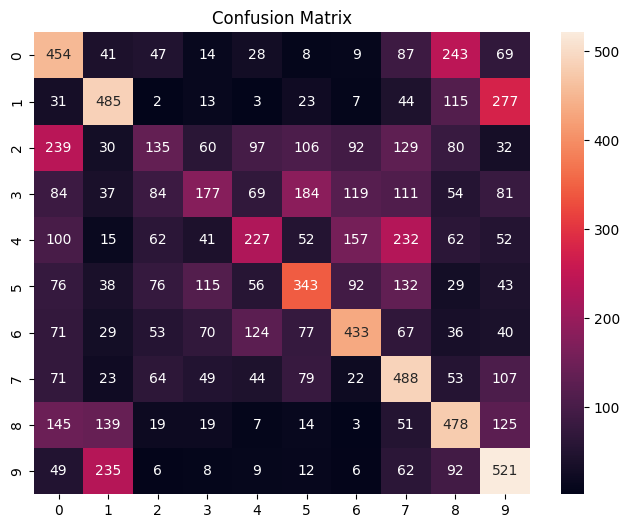

In [ ]:
# Predictions
y_pred = np.argmax(model.predict(x_test), axis=1)

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

yolo object detection

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 10.4 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# Load a model
yolo_model = YOLO('yolov8n.pt')  # load a pretrained

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
#Run detection on image
results = yolo_model('https://ultralytics.com/images/bus.jpg', save=True)


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 304.0ms
Speed: 11.7ms preprocess, 304.0ms inference, 36.4ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict


count detected object

In [ ]:
for r in results:
  print("object detected:",len(r.boxes))

object detected: 6


upload custom images

In [ ]:
from google.colab import files
uploaded = files.upload()

for img in uploaded.keys():
  results = yolo_model(img, save=True)

Saving road-street-car-vehicle.jpg to road-street-car-vehicle.jpg

image 1/1 /content/road-street-car-vehicle.jpg: 448x640 4 cars, 149.2ms
Speed: 3.5ms preprocess, 149.2ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict
